# Supply Chain Sales, Profit, Discount & Delivery Analysis

This notebook explores commercial and operational performance in the DataCo supply-chain dataset. It moves from data validation to four business questions:

1. How are sales and profit changing over time?
2. Which markets contribute the most revenue and profit?
3. How do discounts relate to profitability?
4. Where are delivery delays and late-delivery risks concentrated?

**Important interpretation note:** the dataset contains only January 2018, so 2018 totals are not directly comparable with full-year results for 2015–2017.

## 1. Setup and data loading

The analysis uses pandas for data preparation, Plotly for interactive charts, and seaborn/matplotlib for statistical visuals. Package versions are displayed to improve reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px

%matplotlib inline
sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:,.3f}'.format

In [2]:
# Display charts inline and use a consistent, presentation-friendly theme.
from plotly.offline import init_notebook_mode

init_notebook_mode(connected=True)
px.defaults.template = 'plotly_white'

In [3]:
# Record key package versions for reproducibility.
{
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'plotly': plotly.__version__,
}

{'pandas': '2.3.3', 'numpy': '1.26.4', 'plotly': '5.24.1'}

### Load the dataset

In [2]:
data = './dataset/DataCo_SCM_Data.csv'

df = pd.read_csv(data, encoding='latin1')
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250,314.640,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.090,311.360,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.780,309.720,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860,304.810,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210,298.250,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,1/15/2018 11:24,Standard Class


## 2. Exploratory analysis and data quality

This section establishes the dataset's size, variable types, cardinality, missingness, and duplicate-row count before any business conclusions are drawn. Separating these checks from the later analysis makes assumptions and limitations easier to audit.

In [3]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),"180,519.000",3.498,1.624,0.000,2.000,3.000,5.000,6.000
Days for shipment (scheduled),"180,519.000",2.932,1.374,0.000,2.000,4.000,4.000,4.000
Benefit per order,"180,519.000",21.975,104.434,"-4,274.980",7.000,31.520,64.800,911.800
Sales per customer,"180,519.000",183.108,120.044,7.490,104.380,163.990,247.400,"1,939.990"
Late_delivery_risk,"180,519.000",0.548,0.498,0.000,0.000,1.000,1.000,1.000
Category Id,"180,519.000",31.851,15.640,2.000,18.000,29.000,45.000,76.000
Customer Id,"180,519.000","6,691.379","4,162.918",1.000,"3,258.500","6,457.000","9,779.000","20,757.000"
Customer Zipcode,"180,516.000","35,921.127","37,542.461",603.000,725.000,"19,380.000","78,207.000","99,205.000"
Department Id,"180,519.000",5.443,1.629,2.000,4.000,5.000,7.000,12.000
Order Customer Id,"180,519.000","6,691.379","4,162.918",1.000,"3,258.500","6,457.000","9,779.000","20,757.000"


In [4]:
df.describe(include='object')

,Type,Delivery Status,Category Name,Customer City,Customer Country,Customer Fname,Customer Lname,Customer Segment,Customer State,Customer Street,...,Order City,Order Country,order date (DateOrders),Order Region,Order State,Order Status,Product Image,Product Name,shipping date (DateOrders),Shipping Mode
count,180519,180519,180519,180519,180519,180519,180511,180519,180519,180519,...,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519
unique,4,4,50,563,2,782,1109,3,46,7458,...,3597,164,65752,23,1089,9,118,118,63701,4
top,DEBIT,Late delivery,Cleats,Caguas,EE. UU.,Mary,Smith,Consumer,PR,9126 Wishing Expressway,...,Santo Domingo,Estados Unidos,12/14/2016 12:29,Central America,Inglaterra,COMPLETE,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,1/5/2016 5:58,Standard Class
freq,69295,98977,24551,66770,111146,65150,64104,93504,69373,122,...,2211,24840,5,28341,6722,59491,24515,24515,10,107752


In [5]:
df.shape

(180519, 49)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [7]:
df.nunique()

Type                                  4
Days for shipping (real)              7
Days for shipment (scheduled)         4
Benefit per order                 21998
Sales per customer                 2927
Delivery Status                       4
Late_delivery_risk                    2
Category Id                          51
Category Name                        50
Customer City                       563
Customer Country                      2
Customer Fname                      782
Customer Id                       20652
Customer Lname                     1109
Customer Segment                      3
Customer State                       46
Customer Street                    7458
Customer Zipcode                    995
Department Id                        11
Department Name                      11
Market                                5
Order City                         3597
Order Country                       164
Order Customer Id                 20652
order date (DateOrders)           65752


In [8]:
df['Type'].value_counts()

Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

In [9]:
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

### Data-quality checks

Missing values can bias aggregates if they occur in sales, profit, market, or date fields. Duplicate rows can inflate totals. The following checks make those risks explicit rather than silently modifying the data.

In [10]:
# Missing data 
df.isna().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Market                                0
Order City                            0
Order Country                         0
Order Customer Id                     0
order date (DateOrders)               0


In [11]:
# Duplicated rows 
df.duplicated().sum()

0

In [12]:
int(df.duplicated().sum())

0

### Create order-date features

Dates are converted with explicit error handling. Month number is retained for correct chronological sorting; month name is used only as a readable label.

In [14]:
import datetime as dt

In [15]:
# Invalid date strings become NaT and can be counted during validation.
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)'], errors='coerce'
)

In [16]:
df['Order_Month'] = df['order date (DateOrders)'].dt.month

In [17]:
df['Order_Month_Name'] = df['order date (DateOrders)'].dt.month_name()

In [24]:
df['Order_Year'] = df['order date (DateOrders)'].dt.year

### Create shipping-date features

Shipping dates are parsed independently because operational analyses depend on both order and shipping timestamps.

In [18]:
df['shipping date (DateOrders)'] = pd.to_datetime(
    df['shipping date (DateOrders)'], errors='coerce'
)

In [19]:
df['Shipping_Month'] = df['shipping date (DateOrders)'].dt.month

In [20]:
df['Shipping_Year'] = df['shipping date (DateOrders)'].dt.year

In [21]:
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Order_Month,Order_Month_Name,Shipping_Month,Shipping_Year
0,DEBIT,3,4,91.250,314.640,Advance shipping,0,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,2018-02-03 22:56:00,Standard Class,1,January,2,2018
1,TRANSFER,5,4,-249.090,311.360,Late delivery,1,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,2018-01-18 12:27:00,Standard Class,1,January,1,2018
2,CASH,4,4,-247.780,309.720,Shipping on time,0,73,Sporting Goods,San Jose,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,2018-01-17 12:06:00,Standard Class,1,January,1,2018
3,DEBIT,3,4,22.860,304.810,Advance shipping,0,73,Sporting Goods,Los Angeles,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,2018-01-16 11:45:00,Standard Class,1,January,1,2018
4,PAYMENT,2,4,134.210,298.250,Advance shipping,0,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,2018-01-15 11:24:00,Standard Class,1,January,1,2018


## 3. Sales analysis

Revenue is summarized by year, month, and market. Total profit is included beside sales because high revenue does not necessarily imply high economic value.

In [25]:
class SalesAnalyzer: 

    def __init__(self, df: pd.DataFrame):
        self._df = df.copy()
        self._validate_data()

    def _validate_data(self):
        required_cols = ['Order_Year', 'Order_Month', 'Order_Month_Name', 'Sales', 'Market'] 

        # Check whether all required columns exist
        if not all(col in self._df.columns for col in required_cols):
            missing = [col for col in required_cols if col not in self._df.columns]
            raise ValueError(f"DataFrame is missing required columns: {missing}")

    # Analysis 

    def get_sales_by_year(self) -> pd.DataFrame:
        year_analysis = self._df.groupby('Order_Year').agg(
            Total_Sales=('Sales', 'sum'),
            Total_Profit=('Order Profit Per Order', 'sum'),
            Average_Sales_Per_Order=('Sales', 'mean')
        ).reset_index()
        return year_analysis 

    def get_sales_by_month(self) -> pd.DataFrame:
        month_analysis = self._df.groupby(['Order_Year', 'Order_Month', 'Order_Month_Name']).agg(
            Total_Sales=('Sales', 'sum'),
            Total_Profit=('Order Profit Per Order', 'sum')
        ).reset_index()

        month_analysis = month_analysis.sort_values(by=['Order_Year', 'Order_Month'])
        return month_analysis

    def get_market_performance(self) -> pd.DataFrame:
        # Calculates performance metrics grouped by Market.
        market_analysis = self._df.groupby('Market').agg(
            Total_Sales=('Sales', 'sum'),
            Average_Profit_Ratio=('Order Item Profit Ratio', 'mean'),
            Order_Count=('Order Id', 'nunique')
        ).reset_index()
        
        # Sort markets by total sales for easy comparison
        market_analysis = market_analysis.sort_values(by='Total_Sales', ascending=False)
        return market_analysis

    def get_top_performing_market_month(self, top_n: int = 5) -> pd.DataFrame:
        # Finds the top N market-month combinations based on total Sales.
        
        # Group by all three dimensions: Market, Year, and Month
        grouped_sales = self._df.groupby(['Market', 'Order_Year', 'Order_Month'])['Sales'].sum().reset_index()
        grouped_sales.rename(columns={'Sales': 'Total_Sales'}, inplace=True)
        
        # Find the top N entries
        top_analysis = grouped_sales.nlargest(top_n, 'Total_Sales')
        return top_analysis.reset_index(drop=True)

### Yearly sales

Currency: $ 

The complete years 2015 and 2016 are nearly flat at about **12.3M** each. 2017 reports about **11.8M**, while average sales per row rises to roughly **$222**. The much smaller 2018 value represents January only and should not be read as a full-year collapse.

In [26]:
sales_analyzer = SalesAnalyzer(df)

annual_sales = sales_analyzer.get_sales_by_year()
print("--- Annual Sales Summary ---")
print(annual_sales)

--- Annual Sales Summary ---
   Order_Year    Total_Sales  Total_Profit  Average_Sales_Per_Order
0        2015 12,340,831.431 1,318,856.901                  196.981
1        2016 12,303,817.324 1,310,119.071                  196.704
2        2017 11,808,436.143 1,304,085.111                  221.980
3        2018    331,650.115    33,841.890                  156.218


### Monthly sales

Currency: $

Monthly totals are kept at year-month granularity. This avoids mixing the same calendar month across different years and makes trend or seasonality analysis auditable.

In [27]:
monthly_sales = sales_analyzer.get_sales_by_month()
print("--- Monthly Sales Summary ---")
monthly_sales

--- Monthly Sales Summary ---


,Order_Year,Order_Month,Order_Month_Name,Total_Sales,Total_Profit
0,2015,1,January,"1,051,590.080","111,660.740"
1,2015,2,February,"927,009.898","99,140.660"
2,2015,3,March,"1,051,253.690","113,778.210"
3,2015,4,April,"1,014,463.280","108,083.680"
4,2015,5,May,"1,050,478.440","112,147.900"
5,2015,6,June,"1,024,006.170","110,147.160"
6,2015,7,July,"1,038,081.190","115,624.060"
7,2015,8,August,"1,029,494.691","117,979.770"
8,2015,9,September,"1,018,338.600","113,467.940"
9,2015,10,October,"1,049,154.270","101,757.870"


### Market performance

Europe is the largest market by sales (about **10.87M**), narrowly ahead of LATAM (about **10.28M**). Africa has the smallest sales base but the highest average profit ratio in the current summary, suggesting that scale and margin should be managed as separate objectives.

In [28]:
market_summary = sales_analyzer.get_market_performance()
print("---Market and Sales performance---")
print(market_summary)

---Market and Sales performance---
         Market    Total_Sales  Average_Profit_Ratio  Order_Count
1        Europe 10,872,396.796                 0.122        18561
2         LATAM 10,277,612.841                 0.121        17181
3  Pacific Asia  8,273,743.741                 0.116        17577
4          USCA  5,066,528.711                 0.122         8579
0        Africa  2,294,452.925                 0.125         3854


### Highest-performing market-month combinations

The top three combinations all occur in 2017: Europe in September and August, and LATAM in May. These peaks are useful investigation targets, but they do not by themselves prove recurring seasonality.

In [29]:
top_market_months = sales_analyzer.get_top_performing_market_month(top_n=3)
print("---Top 3 Market/Month Sales---")
print(top_market_months)

---Top 3 Market/Month Sales---
   Market  Order_Year  Order_Month   Total_Sales
0  Europe        2017            9 1,143,775.108
1  Europe        2017            8 1,109,337.171
2   LATAM        2017            5 1,105,485.322


### Sales visualizations

The charts below compare yearly totals, show the full monthly trajectory, and position markets by both revenue and profit. Currency formatting and chronological sorting make the figures easier to interpret.

In [30]:
# yearly sales plot

sales_by_year = df.groupby('Order_Year')['Sales'].sum().reset_index()

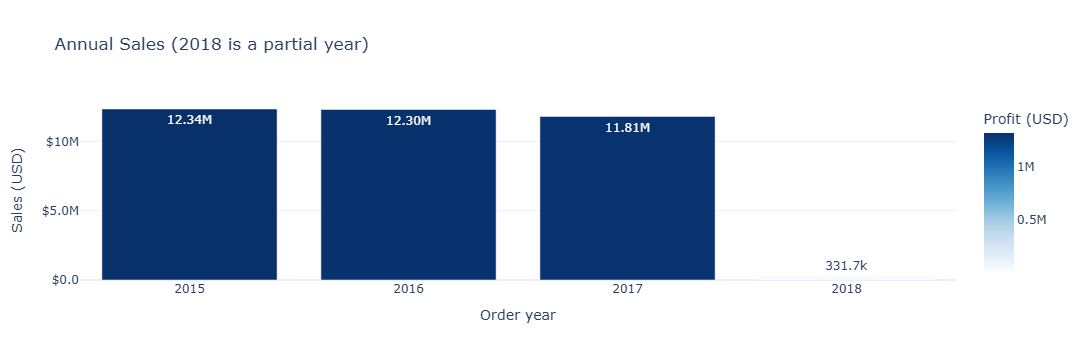

In [105]:
fig = px.bar(
    annual_sales,
    x='Order_Year',
    y='Total_Sales',
    color='Total_Profit',
    text_auto='.4s',
    title='Annual Sales (2018 is a partial year)',
    labels={'Order_Year': 'Order year', 'Total_Sales': 'Sales (USD)', 'Total_Profit': 'Profit (USD)'},
    color_continuous_scale='Blues',
)
fig.update_layout(template='plotly_white', xaxis=dict(dtick=1))
fig.update_yaxes(tickprefix='$', tickformat=',.2s')
fig.show()

In [32]:
# Construct a true date key so month labels remain chronological.
monthly_sales['Period'] = pd.to_datetime(
    monthly_sales['Order_Year'].astype(str) + '-' + monthly_sales['Order_Month'].astype(str) + '-01'
)


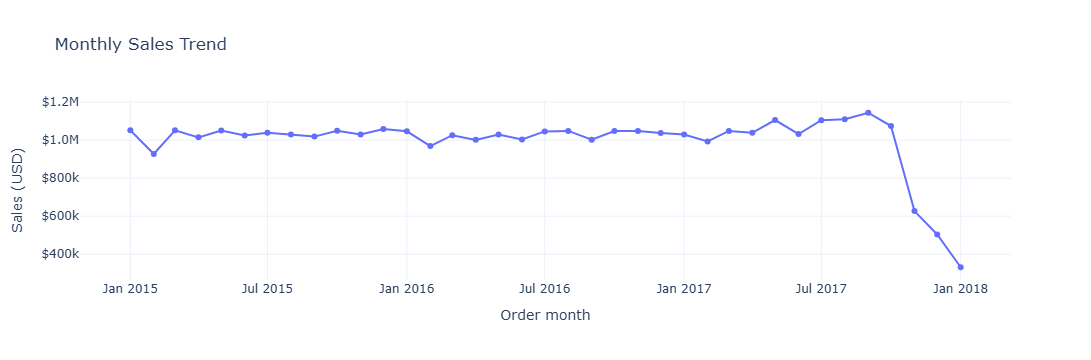

In [33]:
fig = px.line(
    monthly_sales,
    x='Period',
    y='Total_Sales',
    markers=True,
    title='Monthly Sales Trend',
    labels={'Period': 'Order month', 'Total_Sales': 'Sales (USD)'},
)
fig.update_layout(template='plotly_white', hovermode='x unified')
fig.update_yaxes(tickprefix='$', tickformat=',.2s')
fig.show()

In [34]:
# Combine market sales and profit to avoid judging markets on revenue alone.
market_value = (
    df.groupby('Market', as_index=False)
      .agg(Total_Sales=('Sales', 'sum'), Total_Profit=('Order Profit Per Order', 'sum'))
      .sort_values('Total_Sales', ascending=True)
)

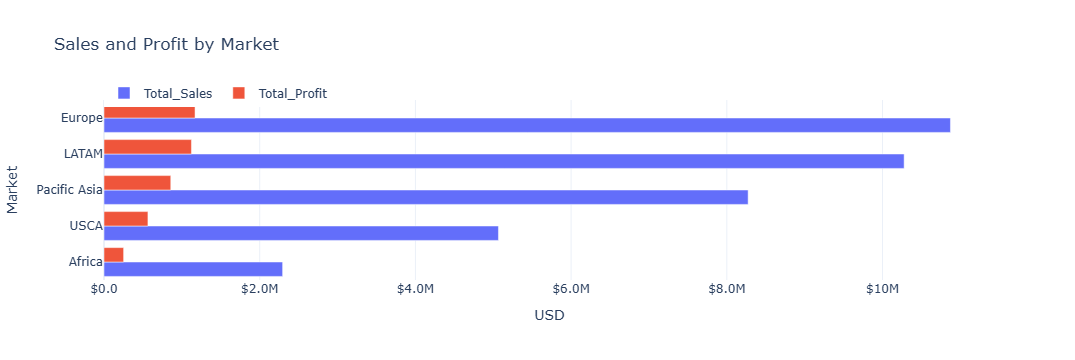

In [93]:
market_long = market_value.melt(
    id_vars='Market', value_vars=['Total_Sales', 'Total_Profit'],
    var_name='Metric', value_name='Amount'
)
fig = px.bar(
    market_long, x='Amount', y='Market', color='Metric', barmode='group',
    orientation='h', title='Sales and Profit by Market',
    labels={'Amount': 'USD', 'Metric': ''},
)
fig.update_layout(template='plotly_white', legend=dict(orientation='h', y=1.12))
fig.update_xaxes(tickprefix='$', tickformat=',.2s')
fig.show()

## 4. Profit analysis

Profit is evaluated independently from revenue. Average profit ratio measures efficiency, while total profit measures absolute contribution; both are needed for a balanced market assessment.

In [36]:
class ProfitAnalyzer(SalesAnalyzer):

    # inheriting all from SalesAnalyzer

    def __init__(self, df: pd.DataFrame):
        # parent class
        super().__init__(df)

    def analyze_profit_margin_by_market(self) -> pd.DataFrame:
       
        
        analysis = self._df.groupby('Market').agg(
            Average_Profit_Ratio=('Order Item Profit Ratio', 'mean'),
            Total_Profit=('Order Profit Per Order', 'sum'),
            Order_Count=('Order Id', 'nunique')
        ).reset_index()
        
        # Sort to easily identify high-margin markets
        analysis = analysis.sort_values(by='Average_Profit_Ratio', ascending=False)
        return analysis

    def identify_low_profit_orders(self, profit_ratio_threshold: float=0.05) -> pd.DataFrame:

        # Filter based on the threshold
        low_profit_orders = self._df[
            self._df['Order Item Profit Ratio'] < profit_ratio_threshold
            ]

        # return relevant columns
        return low_profit_orders[[
            'Order Id', 'Category Name', 'Product Name', 'Order Item Profit Ratio', 'Order Item Total', 'Order Profit Per Order'
        ]]

### Market profit

Africa has the highest average profit ratio (about **12.5%**), but Europe generates the most total profit (about **1.17M**). Pacific Asia has the lowest average ratio in the market summary, making it a useful candidate for cost, product-mix, and discount review.

In [37]:
profit_analyzer = ProfitAnalyzer(df)

In [38]:
# Market-level profit summary, sorted by average margin.
market_profit = profit_analyzer.analyze_profit_margin_by_market()
print("--- Profit Margin Analysis ---")
market_profit

--- Profit Margin Analysis ---


,Market,Average_Profit_Ratio,Total_Profit,Order_Count
0,Africa,0.125,"252,071.180",3854
1,Europe,0.122,"1,169,442.961",18561
4,USCA,0.122,"564,313.780",8579
2,LATAM,0.121,"1,123,321.611",17181
3,Pacific Asia,0.116,"857,753.441",17577


In [39]:
# Sort before plotting so ranking is visually obvious.
profit_by_market = (
    df.groupby('Market', as_index=False)['Order Profit Per Order'].sum()
      .sort_values('Order Profit Per Order', ascending=True)
)

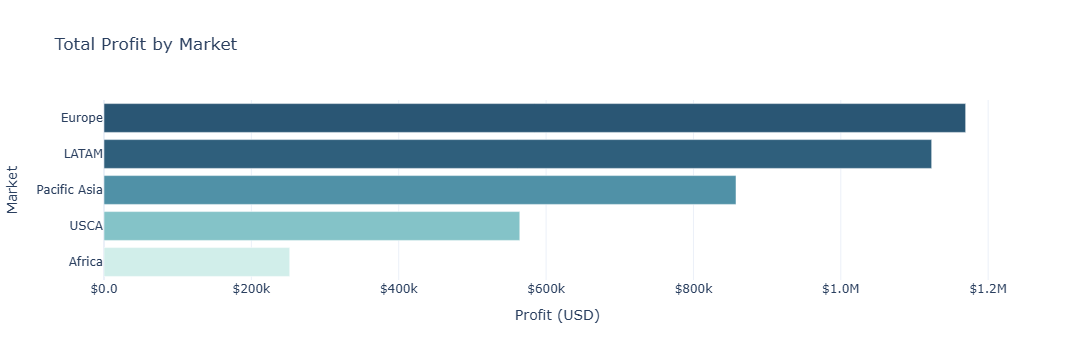

In [40]:
fig = px.bar(
    profit_by_market, x='Order Profit Per Order', y='Market', orientation='h',
    title='Total Profit by Market',
    labels={'Order Profit Per Order': 'Profit (USD)'},
    color='Order Profit Per Order', color_continuous_scale='Teal',
)
fig.update_layout(template='plotly_white', coloraxis_showscale=False)
fig.update_xaxes(tickprefix='$', tickformat=',.2s')
fig.show()

### Low-profit orders

Using a 10% profit-ratio threshold flags **52,937 rows** in the stored result. Because that is a large set, the detailed table is best treated as an investigation queue; the category-level summary below is more actionable for prioritization.

In [41]:
low_profit_items = profit_analyzer.identify_low_profit_orders(profit_ratio_threshold=0.1)
print("---Orders below 10% profit ratio---")
low_profit_items

---Orders below 10% profit ratio---


,Order Id,Category Name,Product Name,Order Item Profit Ratio,Order Item Total,Order Profit Per Order
1,75939,Sporting Goods,Smart watch,-0.800,311.360,-249.090
2,75938,Sporting Goods,Smart watch,-0.800,309.720,-247.780
3,75937,Sporting Goods,Smart watch,0.080,304.810,22.860
5,75935,Sporting Goods,Smart watch,0.060,294.980,18.580
12,75928,Sporting Goods,Smart watch,0.080,262.200,21.760
...,...,...,...,...,...,...
180502,26076,Fishing,Field & Stream Sportsman 16 Gun Fire Safe,0.060,377.980,23.810
180504,26072,Fishing,Field & Stream Sportsman 16 Gun Fire Safe,0.090,363.980,32.030
180506,26064,Fishing,Field & Stream Sportsman 16 Gun Fire Safe,-0.190,351.980,-65.470
180509,26052,Fishing,Field & Stream Sportsman 16 Gun Fire Safe,0.000,335.980,0.000


In [42]:
# Summarize low-profit exposure by category instead of plotting every category total.
low_profit_by_category = (
    low_profit_items.groupby('Category Name', as_index=False)
    .agg(
        Low_Profit_Rows=('Order Id', 'size'),
        Affected_Orders=('Order Id', 'nunique'),
        Total_Profit=('Order Profit Per Order', 'sum'),
        Average_Profit_Ratio=('Order Item Profit Ratio', 'mean'),
    )
    .sort_values('Low_Profit_Rows', ascending=False)
    .head(15)
)

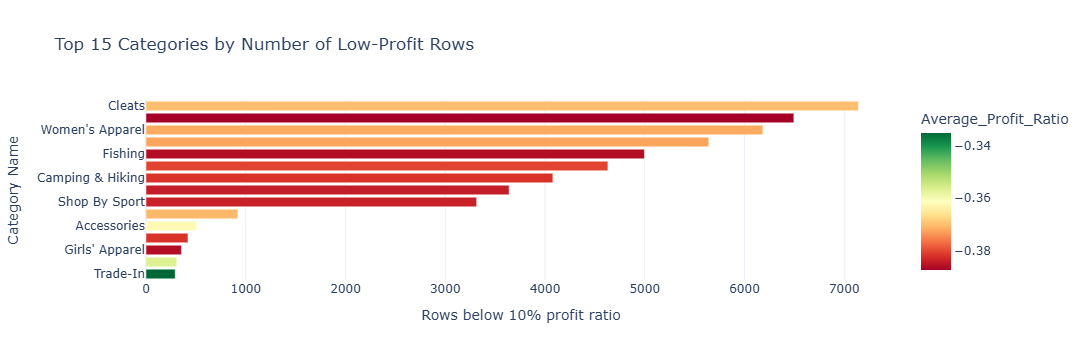

In [43]:
fig = px.bar(
    low_profit_by_category.sort_values('Low_Profit_Rows'),
    x='Low_Profit_Rows', y='Category Name', orientation='h',
    color='Average_Profit_Ratio', color_continuous_scale='RdYlGn',
    title='Top 15 Categories by Number of Low-Profit Rows',
    labels={'Low_Profit_Rows': 'Rows below 10% profit ratio'},
)
fig.update_layout(template='plotly_white')
fig.show()


## 5. Discount analysis

Discount bands are compared using order count, sales, total profit, and average profit ratio. The bands have different volumes, so total profit alone should not be interpreted as discount effectiveness.

In [83]:
class DiscountAnalyzer(ProfitAnalyzer):

    def group_discounts_by_bin(self, bins=None) -> pd.DataFrame:
        # Aggregate volume, sales, and profitability across discount bands.
        if bins is None:
            bins = [0, 0.05, 0.10, 0.15, 0.20, 0.25]
        if len(bins) < 2:
            raise ValueError("At least two bin edges are required.")

        work = self._df.copy()
        labels = [f'{left:.0%} to {right:.0%}' for left, right in zip(bins[:-1], bins[1:])]
        work['Discount_Segment'] = pd.cut(
            work['Order Item Discount Rate'], bins=bins, include_lowest=True,
            right=False, labels=labels
        )
        return (
            work.groupby('Discount_Segment', observed=True)
            .agg(
                Order_Count=('Order Id', 'nunique'),
                Total_Sales=('Sales', 'sum'),
                Total_Profit=('Order Profit Per Order', 'sum'),
                Average_Profit_Ratio=('Order Item Profit Ratio', 'mean'),
                Average_Discount=('Order Item Discount Rate', 'mean'),
            )
            .reset_index()
        )

    def discount_by_product_category(self) -> pd.DataFrame:
        # Compare category economics and discount intensity.
        analysis = self._df.groupby('Category Name', as_index=False).agg(
            Average_Discount_Rate=('Order Item Discount Rate', 'mean'),
            Average_Sales_Per_Row=('Sales', 'mean'),
            Average_Profit_Per_Row=('Order Profit Per Order', 'mean'),
            Average_Profit_Ratio=('Order Item Profit Ratio', 'mean'),
            Total_Quantity_Sold=('Order Item Quantity', 'sum'),
        )
        return analysis.sort_values('Average_Profit_Ratio', ascending=False)

    def discount_by_month(self) -> pd.DataFrame:
        # Compare monthly discount rates and sales chronologically.

        analysis = (
            self._df
            .groupby(["Order_Year", "Order_Month"])
            .agg(
                Average_Discount_Rate=("Order Item Discount Rate", "mean"),
                Total_Sales=("Sales", "sum"),
                Average_Sales_Per_Row=("Sales", "mean"),
                Order_Count=("Order Id", "nunique"),
            )
            .reset_index()
        )
    
        # Convert year and month into a real date for correct chart ordering
        analysis["Period"] = pd.to_datetime(
            analysis["Order_Year"].astype(str)
            + "-"
            + analysis["Order_Month"].astype(str)
            + "-01"
        )
    
        return analysis.sort_values("Period").reset_index(drop=True)

### Sales and profit by discount segment

In the stored results, average profit ratio generally weakens at higher discounts and is lowest in the 20–25% band (about **11.2%**). This is an association, not proof that discounting caused the margin change; product mix and market mix may be confounders.

In [84]:
discount_analyzer = DiscountAnalyzer(df)

In [85]:
# sales and profits based on discount bins 

discount_bins_results = discount_analyzer.group_discounts_by_bin(
    bins=[0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25]
)

print("--- Discount Performance By Discount Segment ---")
discount_bins_results

--- Discount Performance By Discount Segment ---


,Discount_Segment,Order_Count,Total_Sales,Total_Profit,Average_Profit_Ratio,Average_Discount
0,0% to 2%,17045,"4,085,162.228","506,066.363",0.124,0.005
1,2% to 5%,23879,"6,129,539.867","694,559.891",0.119,0.030
2,5% to 10%,29592,"8,173,764.646","943,058.542",0.124,0.068
3,10% to 15%,23689,"6,131,172.787","646,082.469",0.119,0.117
4,15% to 20%,29622,"8,176,530.856","807,926.249",0.118,0.165
5,20% to 25%,9407,"2,044,242.249","177,312.739",0.112,0.200


### Discount Rate and Sales by Year and Month

In [95]:
monthly_discount_result = discount_analyzer.discount_by_month()
monthly_discount_result.head()

,Order_Year,Order_Month,Average_Discount_Rate,Total_Sales,Average_Sales_Per_Row,Order_Count,Period
0,2015,1,0.101,"1,051,590.080",197.593,1787,2015-01-01
1,2015,2,0.102,"927,009.898",196.027,1585,2015-02-01
2,2015,3,0.102,"1,051,253.690",196.056,1781,2015-03-01
3,2015,4,0.102,"1,014,463.280",197.905,1710,2015-04-01
4,2015,5,0.101,"1,050,478.440",196.095,1776,2015-05-01


### Discount and product category

Category-level averages help identify where discount policy and profitability diverge. The analysis uses profit ratio directly; dividing profit by the discount rate can become unstable when discounts are close to zero and is therefore avoided.

In [96]:
category_discount_results = discount_analyzer.discount_by_product_category()
print("--- Discount Analysis by Product ---")
category_discount_results 

--- Discount Analysis by Product ---


,Category Name,Average_Discount_Rate,Average_Sales_Per_Row,Average_Profit_Per_Row,Average_Profit_Ratio,Total_Quantity_Sold
23,Golf Bags & Carts,0.093,169.990,29.673,0.191,61
43,Toys,0.102,11.540,1.703,0.162,529
19,Fitness Accessories,0.103,115.215,17.017,0.151,856
48,Women's Clothing,0.102,215.820,29.389,0.151,650
39,Soccer,0.096,191.863,28.275,0.147,295
35,Men's Golf Clubs,0.099,166.204,19.498,0.146,420
49,Women's Golf Clubs,0.102,246.110,27.783,0.146,403
36,Music,0.101,260.650,33.263,0.143,434
20,Garden,0.101,532.580,69.097,0.143,484
2,Baby,0.104,59.080,7.367,0.139,207


### Discount visualizations

The first chart compares sales and profit totals. The second focuses on average profit ratio, which controls better for the unequal transaction volume across discount bands.

In [97]:
def plot_creator(
    df_analysis: pd.DataFrame,
    title: str = "Sales and Profit by Discount Segment"
): 

    # Setup the plot environment
    sns.set_style("whitegrid")
    fig, ax1 = plt.subplots(figsize=(16, 8))

    # Plot Total Sales (Primary Axis)
    sales_color = 'tab:blue'
    sns.barplot(
        x='Discount_Segment', 
        y='Total_Sales', 
        data=df_analysis, 
        ax=ax1, 
        color=sales_color, 
        alpha=0.7,
        label='Total Sales'
    )
    ax1.set_xlabel("Discount Segment")
    ax1.set_ylabel("Total Sales (USD)", color=sales_color)
    ax1.tick_params(axis='y', labelcolor=sales_color)
    
    # Rotate x-labels for better readability
    plt.xticks(rotation=45, ha='right')

    # Create Total Profit (Secondary Axis)
    ax2 = ax1.twinx()  # Instantiate a second y-axis that shares the same x-axis
    profit_color = 'tab:red'
    
    # Plot Total Profit as a line on the secondary axis
    ax2.plot(
        df_analysis['Discount_Segment'], 
        df_analysis['Total_Profit'], 
        color=profit_color, 
        marker='o', 
        linewidth=2,
        label='Total Profit'
    )
    ax2.set_ylabel("Total Profit (USD)", color=profit_color)
    ax2.tick_params(axis='y', labelcolor=profit_color)

    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96]) 

    plt.show()

In [98]:
# Use the same bins as the summary table for consistent interpretation.
discount_results_df = discount_analyzer.group_discounts_by_bin(
    bins=[0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25]
)

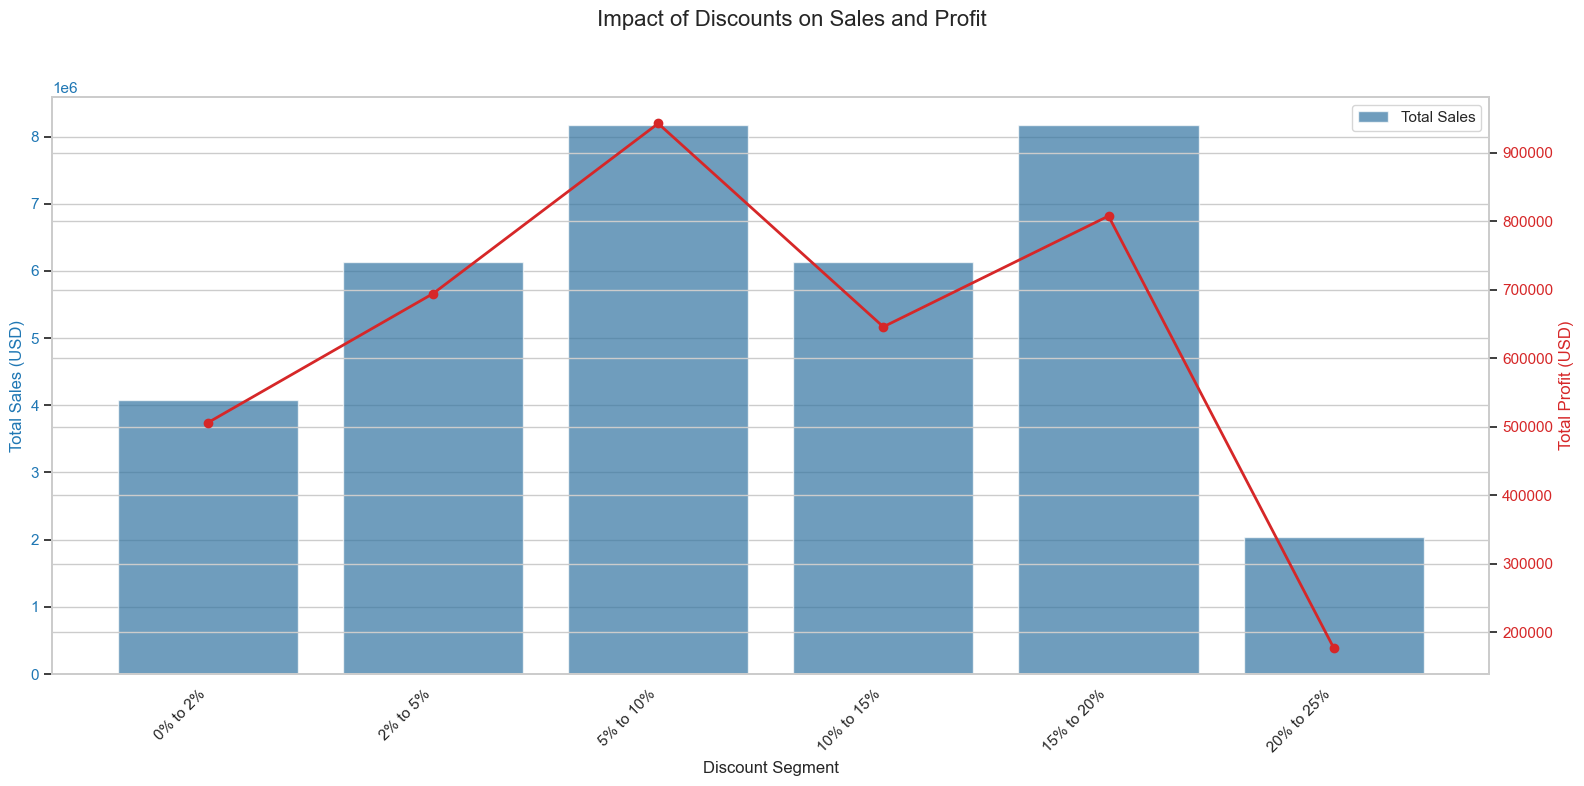

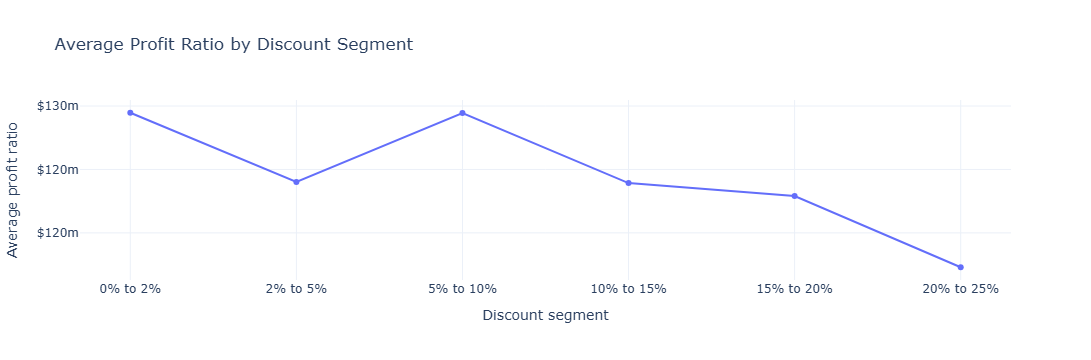

In [99]:
plot_creator(
    df_analysis=discount_results_df,
    title='Impact of Discounts on Sales and Profit',
)

fig = px.line(
    discount_results_df,
    x='Discount_Segment', y='Average_Profit_Ratio', markers=True,
    title='Average Profit Ratio by Discount Segment',
    labels={'Discount_Segment': 'Discount segment', 'Average_Profit_Ratio': 'Average profit ratio'},
)

fig.update_layout(template='plotly_white', hovermode='x unified')
fig.update_yaxes(tickprefix='$', tickformat=',.2s')
fig.show()

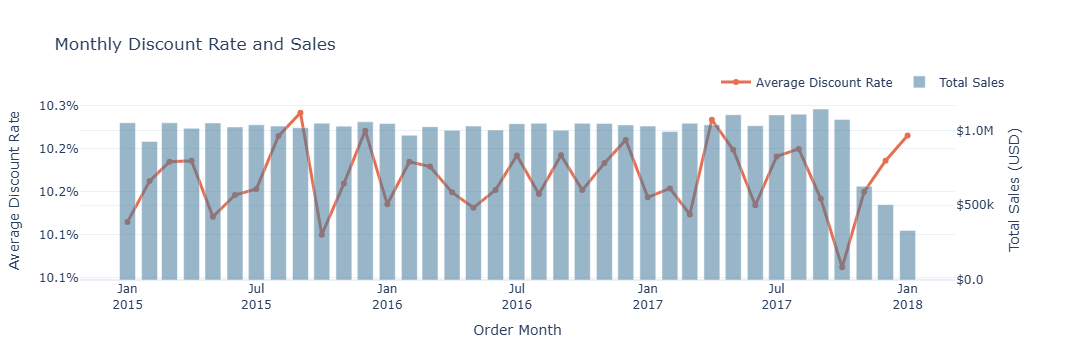

In [100]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Average monthly discount rate
fig.add_trace(
    go.Scatter(
        x=monthly_discount_result["Period"],
        y=monthly_discount_result["Average_Discount_Rate"],
        name="Average Discount Rate",
        mode="lines+markers",
        line=dict(color="#E76F51", width=3),
        hovertemplate=(
            "Month: %{x|%b %Y}<br>"
            "Average discount: %{y:.2%}"
            "<extra></extra>"
        ),
    ),
    secondary_y=False,
)

# Total monthly sales
fig.add_trace(
    go.Bar(
        x=monthly_discount_result["Period"],
        y=monthly_discount_result["Total_Sales"],
        name="Total Sales",
        marker_color="#457B9D",
        opacity=0.55,
        hovertemplate=(
            "Month: %{x|%b %Y}<br>"
            "Sales: $%{y:,.0f}"
            "<extra></extra>"
        ),
    ),
    secondary_y=True,
)

fig.update_layout(
    title="Monthly Discount Rate and Sales",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
    ),
)

fig.update_xaxes(
    title_text="Order Month",
    tickformat="%b<br>%Y",
)

fig.update_yaxes(
    title_text="Average Discount Rate",
    tickformat=".1%",
    secondary_y=False,
)

fig.update_yaxes(
    title_text="Total Sales (USD)",
    tickprefix="$",
    tickformat=",.2s",
    secondary_y=True,
)

fig.show()

## 6. Shipment and delivery analysis

Delivery delay is defined as actual shipping days minus scheduled shipping days. Positive values indicate late shipment; zero indicates on-time shipment; negative values indicate shipment earlier than scheduled.

In [101]:
class DeliveryAnalyzer(ProfitAnalyzer):
    # Analyze schedule adherence and late-delivery exposure.

    def __init__(self, df: pd.DataFrame):
        super().__init__(df)

    def calculate_delivery_delay(self) -> pd.DataFrame:
        work = self._df.copy()
        work['Delivery_Delay_Days'] = (
            work['Days for shipping (real)']
            - work['Days for shipment (scheduled)']
        )
        work['Schedule_Result'] = np.select(
            [work['Delivery_Delay_Days'] > 0, work['Delivery_Delay_Days'] < 0],
            ['Late', 'Early'], default='On time'
        )
        return work[[
            'Order Id', 'Market', 'Shipping Mode', 'Delivery Status',
            'Days for shipping (real)', 'Days for shipment (scheduled)',
            'Delivery_Delay_Days', 'Schedule_Result'
        ]]


delivery_analyzer = DeliveryAnalyzer(df)
delivery_delay = delivery_analyzer.calculate_delivery_delay()
delivery_delay.head()

,Order Id,Market,Shipping Mode,Delivery Status,Days for shipping (real),Days for shipment (scheduled),Delivery_Delay_Days,Schedule_Result
0,77202,Pacific Asia,Standard Class,Advance shipping,3,4,-1,Early
1,75939,Pacific Asia,Standard Class,Late delivery,5,4,1,Late
2,75938,Pacific Asia,Standard Class,Shipping on time,4,4,0,On time
3,75937,Pacific Asia,Standard Class,Advance shipping,3,4,-1,Early
4,75936,Pacific Asia,Standard Class,Advance shipping,2,4,-2,Early


### Delivery performance visualizations

The schedule-result chart communicates the overall scale of early, on-time, and late shipments. The heatmap then shows whether late-shipment rates are concentrated in particular market and shipping-mode combinations.

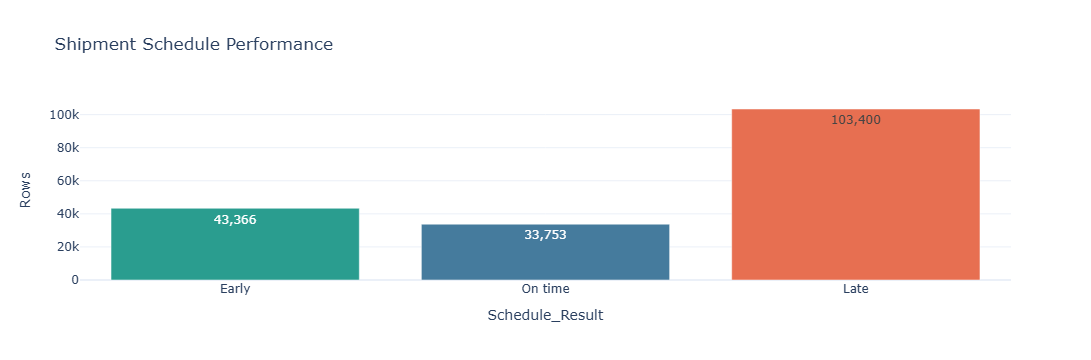

In [102]:
schedule_summary = (
    delivery_delay['Schedule_Result'].value_counts()
    .rename_axis('Schedule_Result').reset_index(name='Rows')
)
fig = px.bar(
    schedule_summary, x='Schedule_Result', y='Rows', color='Schedule_Result',
    title='Shipment Schedule Performance', text_auto=',',
    category_orders={'Schedule_Result': ['Early', 'On time', 'Late']},
    color_discrete_map={'Early': '#2A9D8F', 'On time': '#457B9D', 'Late': '#E76F51'},
)
fig.update_layout(template='plotly_white', showlegend=False)
fig.show()

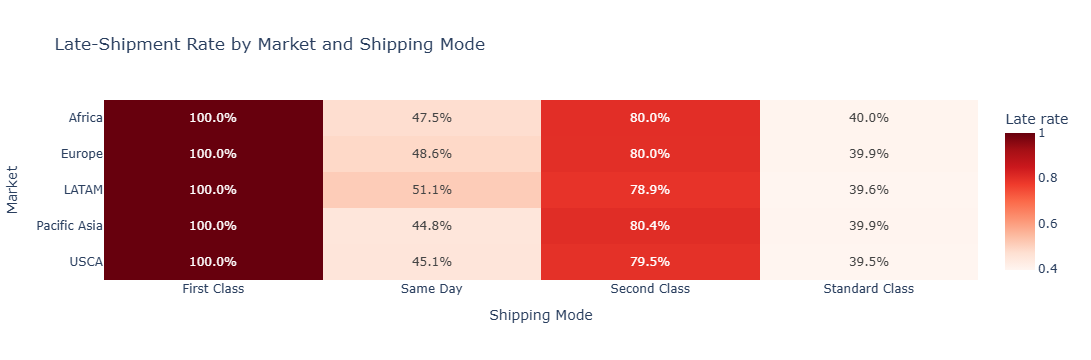

In [103]:
late_rate = (
    delivery_delay.assign(Is_Late=delivery_delay['Delivery_Delay_Days'].gt(0))
    .pivot_table(index='Market', columns='Shipping Mode', values='Is_Late', aggfunc='mean')
)
fig = px.imshow(
    late_rate, text_auto='.1%', aspect='auto', color_continuous_scale='Reds',
    title='Late-Shipment Rate by Market and Shipping Mode',
    labels={'color': 'Late rate'},
)
fig.update_layout(template='plotly_white')
fig.show()

## 7. Integrated diagnostic view

A correlation heatmap is a compact screening tool for linear relationships among commercial and operational measures. It should guide follow-up questions rather than be treated as causal evidence.

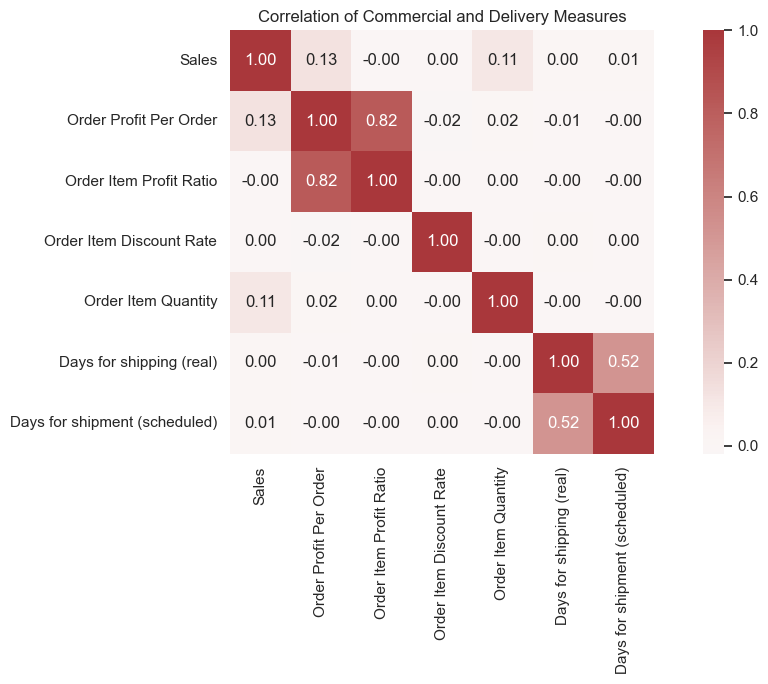

In [104]:
diagnostic_columns = [
    'Sales', 'Order Profit Per Order', 'Order Item Profit Ratio',
    'Order Item Discount Rate', 'Order Item Quantity',
    'Days for shipping (real)', 'Days for shipment (scheduled)'
]
corr = df[diagnostic_columns].corr(numeric_only=True)

plt.figure(figsize=(11, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True)
plt.title('Correlation of Commercial and Delivery Measures')
plt.tight_layout()
plt.show()


## 8. Conclusions and recommended next steps

### Main findings

- **Revenue concentration:** Europe and LATAM are the largest markets by sales; Europe also contributes the most total profit.
- **Margin versus scale:** Africa leads on average profit ratio despite its smaller sales base, showing why revenue and profitability should be reviewed together.
- **Discount signal:** the highest discount band in the stored summary has the weakest average profit ratio. Category and market controls are needed before making a policy change.
- **Time coverage:** 2018 contains only January, so full-year comparisons should focus on 2015–2017 or use like-for-like month comparisons.
- **Operational focus:** schedule adherence should be monitored by both market and shipping mode to locate concentrated late-shipment risk.
